In [1]:
!pip install torchmetrics
!pip install pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 427.8/427.8 kB 4.2 MB/s eta 0:00:00


In [2]:
import torch
import torchmetrics

import torchvision

from torchvision.models.detection.faster_rcnn import fasterrcnn_resnet50_fpn

import cv2

import numpy as np

import os

import sklearn

import random

import json

from PIL import Image

from torch.utils.data import DataLoader, Dataset

In [3]:
import torch

import os

import random

import json

from sklearn.preprocessing import LabelEncoder

from PIL import Image

from torch.utils.data import DataLoader, Dataset

from torchvision.transforms import v2 as T


torch.cuda.empty_cache()
def get_transform(train):

    transform = []

    if train and random.random() < 0.5:

        transform.append(T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.2)),

    transform.append(T.ToTensor()),

    transform.append(T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]))

    return T.Compose(transform)



class trafficSignDataset(Dataset):

    def __init__(self, img_dir, annotation, subset, transforms=None):

        self.img_dir = os.path.join(img_dir, subset)

        self.subset = subset

        self.transforms = transforms

        with open(annotation) as f:

            self.annotations = json.load(f) 

        self.image_ids = [

            img_id for img_id, img_info in self.annotations['imgs'].items() if img_info['path'].startswith(subset)

        ]

        self.imgs = [image for image in sorted(os.listdir(self.img_dir)) if image[-4:]=='.jpg']

        self.classes = ['pl80', 'pl5', 'pl120', 'p26', 'il60', 'pl60', 'pl100', 'pl30', 'p12',
                        'il50', 'il90', 'ph5', 'pn', 'w57', 'p27', 'p18', 'i4', 'pm20', 'p13',
                        'il110', 'il80', 'pne', 'pm30', 'pss', 'pa13', 'i2', 'p9', 'p10', 'p29',
                        'i5', 'p11', 'pmb', 'pr40', 'p6', 'pl20', 'pl110', 'p17', 'p5', 'ip', 'w3',
                        'pl40', 'pr20', 'pr50', 'p23', 'p3', 'ph4.2', 'pcr', 'p16', 'iz', 'p8',
                        'ph2.5', 'pb', 'ph3', 'ph2.2', 'il70', 'pr30', 'pl50', 'i2r', 'p1n', 'wc',
                        'pbp', 'ph4.5', 'i4l', 'p14', 'pm10', 'pw4', 'i13', 'pw3.2', 'pmr', 'ph3.5',
                        'pbm', 'pm55', 'il100', 'p2', 'pm15', 'w20', 'pctl', 'pl70', 'pl10', 'w30',
                        'pl90', 'pr60', 'ph4', 'pcd', 'w45', 'pg', 'w22', 'w55', 'pl15', 'w13', 'ph2',
                        'w42', 'pm35', 'p15', 'w34', 'pl35', 'p4', 'pdd', 'w32', 'pm2', 'pr70', 'pr80',
                        'pmblr', 'w35', 'w59', 'pcl', 'p19', 'pa12', 'w41', 'w18', 'phcs', 'i14',
                        'pm40', 'w38', 'w12', 'pw3', 'pnlc', 'pa10', 'p25', 'w63', 'p1', 'i10',
                        'w47', 'phclr', 'pt', 'pl25', 'pm50', 'w37', 'ph3.2', 'ph2.4', 'im', 'w58',
                        'pa14', 'ps', 'w21', 'i12', 'i1', 'w46', 'pn-2', 'pm5', 'ph4.8', 'ph4.3',
                        'i3', 'ph2.8', 'pw3.5', 'pm8', 'p28', 'ph1.8', 'ph2.1']


    def __getitem__(self, idx):

        image_id = self.image_ids[idx]

        img_info = self.annotations['imgs'][image_id]

        img_path = os.path.join(img_dir, img_info['path'])

        image = Image.open(img_path).convert("RGB")

        

        boxes = []

        labels = []

        img_id = [int(image_id)]

        for obj in img_info['objects']:

            xmin, ymin, xmax, ymax = obj['bbox']['xmin'], obj['bbox']['ymin'], obj['bbox']['xmax'], obj['bbox']['ymax']

            boxes.append([xmin, ymin, xmax, ymax])

            labels.append(obj['category'])

        if self.transforms is not None:

            image = self.transforms(image)

        integer_labels = LabelEncoder().fit_transform(labels)

        target = {

            'boxes' : torch.tensor(boxes, dtype=torch.float32),

            'labels': torch.tensor(integer_labels, dtype=torch.long),

            'image_id': torch.tensor(img_id, dtype=torch.long)

        }

        return image, target

    def __len__(self):

        return len(self.image_ids)

    

#Inference    

img_dir = r'../Preprocessing/TT100k'

annotation_file = r"../Preprocessing/TT100k/annotations_modified.json"



train_dataset = trafficSignDataset(img_dir, annotation_file, subset="train", transforms=get_transform(train=True))

val_dataset = trafficSignDataset(img_dir, annotation_file, subset="val", transforms=get_transform(train=False))

test_dataset = trafficSignDataset(img_dir, annotation_file, subset="test", transforms=get_transform(train=False))



train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=lambda x: tuple(zip(*x)),num_workers=3)

val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=lambda x: tuple(zip(*x)),num_workers=3)

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=lambda x: tuple(zip(*x)),num_workers=3)

/opt/conda/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [4]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

img, target = train_dataset[1]

print(img.shape, target)

print(len(train_loader), len(val_loader), len(test_loader))

43516 2446 3414
torch.Size([3, 800, 800]) {'boxes': tensor([[316.3676, 353.4961, 326.0365, 366.2593],
        [430.0742, 363.5519, 437.8094, 371.6739],
        [415.3789, 363.9387, 422.3391, 372.4474],
        [423.1133, 362.7785, 430.0749, 372.4470],
        [280.0125, 355.0434, 288.5211, 366.2599]]), 'labels': tensor([0, 1, 2, 3, 4]), 'image_id': tensor([84351])}
2720 153 214


In [5]:
from torchvision.models.detection.faster_rcnn import fasterrcnn_resnet50_fpn, FastRCNNPredictor


def get_model(num_classes):

    model = fasterrcnn_resnet50_fpn(weights="DEFAULT", min_size=800, max_size=800)

    in_features = model.roi_heads.box_predictor.cls_score.in_features

    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [6]:
from torchvision.ops import box_iou
from torchmetrics.detection.mean_ap import MeanAveragePrecision
def testModel(model,dataloader,pred=[],rcl=[],acry=[],mAP_list=[],mAP75_list=[]):
    model.to(device)
    model.eval()
    # box_lists = []
    # label_lists = []
    score_lists = []
    # targets =[]
    metric = MeanAveragePrecision()
    total_TP = 0
    total_FP = 0
    total_FN = 0
    for ims,tgs in dataloader:
                
                targets_box =[]
                targets_label = []
        
                images = list(image.to(device) for image in ims)
                
                targets = [{k: v.to(device) for k, v in t.items()} for t in tgs]
                for target in targets:
                        targets_box.append(target['boxes'])
                        targets_label.append(target['labels'])
                i=0
                with torch.no_grad():
                    predictions = model(images)
                    results = []
                    targets_list = []
                    for output in (predictions):
                        boxes = output['boxes']
                        scores = output['scores']
                        labels = output['labels']
            
                        # Áp dụng NMS xóa các bouding box chồng lên nhau
                        nms_threshold = 0.5
                        keep_indices = torchvision.ops.nms(boxes, scores, nms_threshold)
    
                        # print(keep_indices)
                        # 
                        filtered_boxes = boxes[keep_indices]
                        filtered_scores = scores[keep_indices]
                        filtered_labels = labels[keep_indices]
                        # Dự đoán (boxes, labels, scores)
                        
                        tp,fp,fn = Caculate_TP(filtered_boxes,targets_box[i])   
                        total_TP += tp
                        total_FP += fp
                        total_FN += fn
                        # Thêm vào các predictions và targets để tính mAP
                        results.append({
                            'boxes': filtered_boxes,
                            'scores': filtered_scores,
                            'labels': filtered_labels
                        })
                        targets_list.append({
                            'boxes': targets_box[i],
                            'labels': targets_label[i]
                        })
                        i +=1 
                    metric.update(preds=results, target=targets_list)
    # Tính mAP sau khi kết thúc
    mAP = metric.compute()
    print(f"mAP: {mAP}")
    print(f"TP: {total_TP},FP: {total_FP},FN: {total_FN}")
    
    # Tính Precision, Recall, Accuracy
    precision = total_TP / (total_TP + total_FP) if (total_TP + total_FP) > 0 else 0
    recall = total_TP / (total_TP + total_FN) if (total_TP + total_FN) > 0 else 0
    accuracy = total_TP / (total_TP + total_FP + total_FN) if (total_TP + total_FP + total_FN) > 0 else 0

    pred.append(precision)
    rcl.append(recall) 
    acry.append(accuracy)
    mAP_list.append(mAP['map_50'])
    mAP75_list.append(mAP['map_75'])
    
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, Accuracy: {accuracy:.4f}")


In [7]:
from torchvision.ops import box_iou

def Caculate_TP(pred_box,target_box):
    iou_threshold = 0.5
    
    # Khởi tạo TP, FP, FN
    TP = 0
    FP = 0
    FN = 0
    
    # tính iou_scores
    iou_scores = box_iou(pred_box, target_box)

    # Duyệt qua từng box dự đoán và kiểm tra nếu có IoU >= ngưỡng với một Ground Truth box
    for i in range(iou_scores.size(0)):
        if (iou_scores[i] >= iou_threshold).any():  # Nếu box dự đoán i có IoU >= ngưỡng với bất kỳ Ground Truth box nào
            TP += 1
        else:
            FP += 1
    
    # Kiểm tra FN cho từng Ground Truth box
    for j in range(iou_scores.size(1)):
        if (iou_scores[:, j] < iou_threshold).all():  # Nếu không có box dự đoán nào đạt ngưỡng với Ground Truth box j
            FN += 1
    # print(TP,FP,FN)
    return TP,FP,FN

In [8]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from transformers import AdamW
from transformers import get_linear_schedule_with_warmup


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Running on device: {}".format(device))


def train_model(num_epochs,pred_values,recall_values,accuracy_values,mAP50_values,mAP75_values):
    num_classes = 150 # 149 classes + background
    earlyCount =0
    model = get_model(num_classes)    
    model.to(device)
    optimizer = optim.SGD(lr=1E-3, params=filter(lambda p: p.requires_grad, model.parameters()), weight_decay=1E-4, momentum=0.9)
    #scheduler
    num_training_steps = len(train_loader) * num_epochs
    num_warmup_steps = int(0.15 * num_training_steps)  # 15% of total steps
    
    # Create the learning rate scheduler with warmup
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=num_warmup_steps, num_training_steps=num_training_steps)
    best_train_loss = float("inf")

    bestIndex = 0

    for i in range(num_epochs):
        model.train()
        #ims, tgs = next(iter(train_loader))
        total_loss = 0
        for ims,tgs in train_loader:
            optimizer.zero_grad()
    
            images = list(image.to(device) for image in ims)
    
            targets = [{k: v.to(device) for k, v in t.items()} for t in tgs]
    
            batch_losses = model(images, targets)
            loss = batch_losses['loss_classifier'] + batch_losses['loss_box_reg'] + batch_losses['loss_rpn_box_reg']+batch_losses['loss_objectness']
    
            loss.backward()
            optimizer.step()
            scheduler.step() #cập nhập learning rate
            
            total_loss += loss.item()
            
        loss_values.append(total_loss/len(train_loader))
            
        print('Finished epoch {}'.format(i+1))

        print("Validation")
        testModel(model,val_loader,pred_values,recall_values,accuracy_values,mAP50_values,mAP75_values)
        
        #PRINT
        
        print(f"Train loss: {total_loss/len(train_loader):.4f}\n")
        
        train_loss = total_loss/len(train_loader)
        
        # Kiểm tra Early Stopping/ lưu mô hình tốt nhất
        if train_loss < best_train_loss:
            best_train_loss = train_loss
            bestIndex = i
            earlyCount= 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            earlyCount += 1

        if earlyCount > 4:
            print(f"Early Stopping at epoch {i}")
            break
    print(f"Best Loss: {best_train_loss:.4f} at epoch{bestIndex}\n")
    print('Done Training...')
    


Running on device: cuda


In [9]:
loss_values = []  
pred_values = []
recall_values = []
accuracy_values = []
mAP50_values = []
mAP75_values = []

num_epochs = 8
train_model(num_epochs,pred_values,recall_values,accuracy_values,mAP50_values,mAP75_values)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:00<00:00, 195MB/s]


Finished epoch 1
Validation
mAP: {'map': tensor(0.0597), 'map_50': tensor(0.0821), 'map_75': tensor(0.0716), 'map_small': tensor(0.0540), 'map_medium': tensor(0.1109), 'map_large': tensor(0.1643), 'mar_1': tensor(0.0676), 'mar_10': tensor(0.1277), 'mar_100': tensor(0.1282), 'mar_small': tensor(0.1191), 'mar_medium': tensor(0.1995), 'mar_large': tensor(0.2472), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.int32)}
TP: 7384,FP: 13114,FN: 681
Precision: 0.3602, Recall: 0.9156, Accuracy: 0.3486
Train loss: 0.3901

Finished epoch 2
Validation
mAP: {'map': tensor(0.2567), 'map_50': tensor(0.3162), 'map_75': tensor(0.2911), 'map_small': tensor(0.2340), 'map_medium': tensor(0.4413), 'map_large': tensor(0.5257), 'mar_1': tensor(0.2205), 'mar_10': tensor(0.2926), 'mar_100': tensor(0.2928), 'mar_small': tensor(0.2721), 'mar_medium': tensor(0.4659), 'mar_large': tensor(0.5250), 'map_per_class': tensor(-1.), 'mar_100_pe

In [10]:
import csv
epochs = list(range(1, num_epochs + 1))
data = zip(epochs, loss_values, pred_values,recall_values,accuracy_values, mAP50_values,mAP75_values)
csv_filename = './output/train/training_results.csv'
os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
with open(csv_filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    
    # Ghi tiêu đề cột
    writer.writerow(['Epoch', 'Train Loss', 'prediction','Recall','Accurancy' ,'mAP50','mAP75'])
    # Ghi các giá trị
    writer.writerows(data)

print(f'Data has been written to {csv_filename}')

Data has been written to output/train/training_results.csv


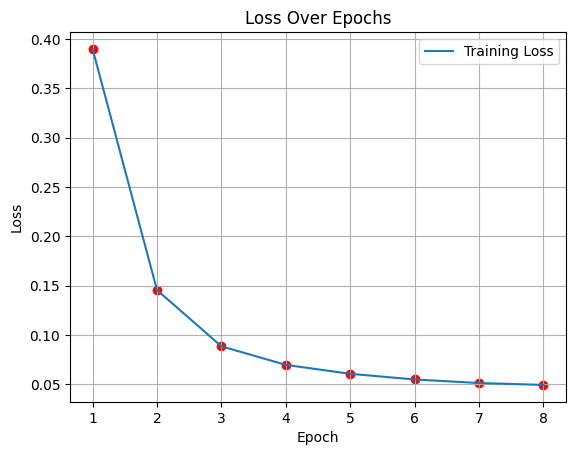

In [11]:
plt.plot(range(1, num_epochs + 1), loss_values,label="Training Loss")
plt.scatter(range(1, num_epochs + 1), loss_values, color='red', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.grid()
plt.legend()
plt.savefig("output/train/Loss.jpg")
plt.show()

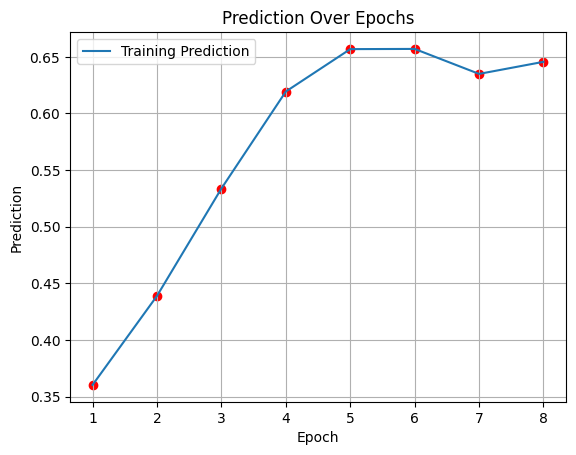

In [12]:
plt.plot(range(1, num_epochs + 1), pred_values, label="Training Prediction")
plt.scatter(range(1, num_epochs + 1), pred_values, color='red', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Prediction')
plt.title('Prediction Over Epochs')
plt.grid()
plt.legend()
plt.savefig("output/train/predic.jpg")
plt.show()

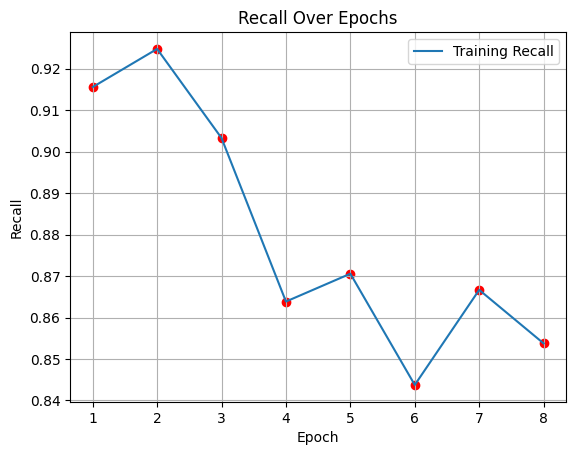

In [13]:
plt.plot(range(1, num_epochs + 1), recall_values, label="Training Recall")
plt.scatter(range(1, num_epochs + 1), recall_values, color='red', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Recall Over Epochs')
plt.grid()
plt.legend()
plt.savefig("output/train/Recall.jpg")
plt.show()

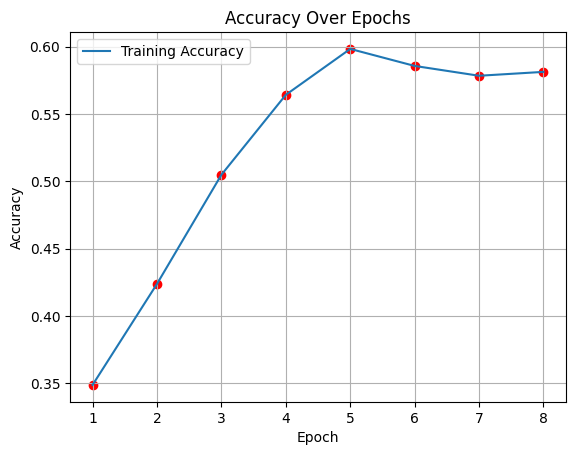

In [14]:
plt.plot(range(1, num_epochs + 1), accuracy_values, label="Training Accuracy")
plt.scatter(range(1, num_epochs + 1), accuracy_values, color='red', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Epochs')
plt.grid()
plt.legend()
plt.savefig("output/train/Accuracy.jpg")
plt.show()

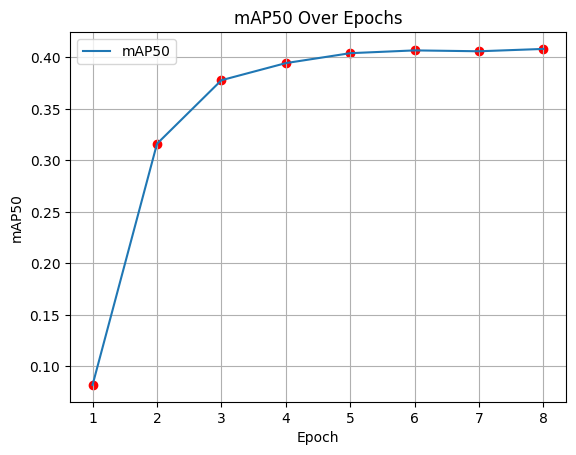

In [15]:
plt.plot(range(1, num_epochs + 1), mAP50_values, label="mAP50")
plt.scatter(range(1, num_epochs + 1), mAP50_values, color='red', marker='o')
plt.xlabel('Epoch')
plt.ylabel('mAP50')
plt.title('mAP50 Over Epochs')
plt.grid()
plt.legend()
plt.savefig("output/train/mAP50.jpg")
plt.show()

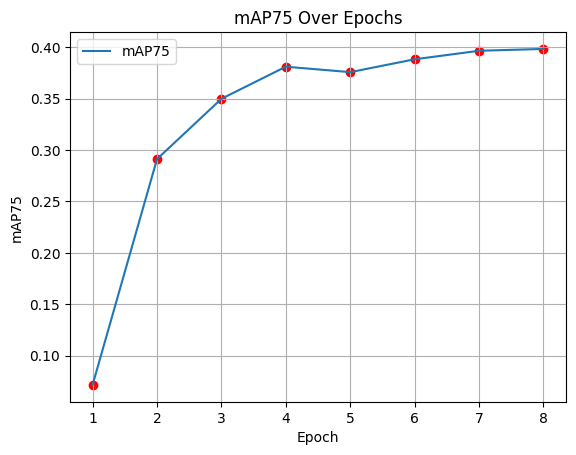

In [16]:
plt.plot(range(1, num_epochs + 1), mAP75_values, label="mAP75")
plt.scatter(range(1, num_epochs + 1), mAP75_values, color='red', marker='o')
plt.xlabel('Epoch')
plt.ylabel('mAP75')
plt.title('mAP75 Over Epochs')
plt.grid()
plt.legend()
plt.savefig("output/train/mAP75.jpg")
plt.show()

ĐÁNH GIÁ TRÊN TẬP TEST

In [17]:
model = get_model(150)
model.load_state_dict(torch.load("../best_model.pth"))
model.to(device)
model.eval()

pred_test = []
recall_test = []
accuracy_test = []
mAP50_test = []
mAP75_test = []

pred_train = []
recall_train = []
accuracy_train = []
mAP50_train = []
mAP75_train = []

testModel(model,test_loader,pred_test,recall_test,accuracy_test,mAP50_test,mAP75_test)
testModel(model,train_loader,pred_train,recall_train,accuracy_train,mAP50_train,mAP75_train)


/tmp/ipykernel_23/2555843345.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))


mAP: {'map': tensor(0.1017), 'map_50': tensor(0.1177), 'map_75': tensor(0.1068), 'map_small': tensor(0.0926), 'map_medium': tensor(0.2728), 'map_large': tensor(0.4927), 'mar_1': tensor(0.0933), 'mar_10': tensor(0.1266), 'mar_100': tensor(0.1267), 'mar_small': tensor(0.1180), 'mar_medium': tensor(0.3072), 'mar_large': tensor(0.5444), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13],
       dtype=torch.int32)}
TP: 8099,FP: 7959,FN: 1750
Precision: 0.5044, Recall: 0.8223, Accuracy: 0.4548
mAP: {'map': tensor(0.5384), 'map_50': tensor(0.5988), 'map_75': tensor(0.5677), 'map_small': tensor(0.5304), 'map_medium': tensor(0.5652), 'map_large': tensor(0.6476), 'mar_1': tensor(0.4310), 'mar_10': tensor(0.5547), 'mar_100': tensor(0.5547), 'mar_small': tensor(0.5480), 'mar_medium': tensor(0.5747), 'mar_large': tensor(0.6540), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([ 

In [18]:
data = zip(pred_test,recall_test,accuracy_test,mAP50_test,mAP75_test)
csv_filename = './output/test/test_results.csv'
os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
with open(csv_filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    
    # Ghi tiêu đề cột
    writer.writerow(['prediction','Recall','Accuracy' ,'mAP50','mAP75'])
    # Ghi các giá trị
    writer.writerows(data)

print(f'Data has been written to {csv_filename}')

Data has been written to output/test/test_results.csv


In [19]:
data = zip(pred_train,recall_train,accuracy_train,mAP50_train,mAP75_train)
csv_filename = './output/test/train_results.csv'
os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
with open(csv_filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    
    # Ghi tiêu đề cột
    writer.writerow(['prediction','Recall','Accuracy' ,'mAP50','mAP75'])
    # Ghi các giá trị
    writer.writerows(data)

print(f'Data has been written to {csv_filename}')

Data has been written to output/test/train_results.csv


DỰ ĐOÁN HÌNH ẢNH

In [20]:
# import torch
# import torchvision
# from torchvision import transforms as T

# from PIL import Image
# import cv2
# import matplotlib.pyplot as plt

# className = ['pl80', 'pl5', 'pl120', 'p26', 'il60', 'pl60', 'pl100', 'pl30', 'p12',
#                 'il50', 'il90', 'ph5', 'pn', 'w57', 'p27', 'p18', 'i4', 'pm20', 'p13',
#                 'il110', 'il80', 'pne', 'pm30', 'pss', 'pa13', 'i2', 'p9', 'p10', 'p29',
#                 'i5', 'p11', 'pmb', 'pr40', 'p6', 'pl20', 'pl110', 'p17', 'p5', 'ip', 'w3',
#                 'pl40', 'pr20', 'pr50', 'p23', 'p3', 'ph4.2', 'pcr', 'p16', 'iz', 'p8',
#                 'ph2.5', 'pb', 'ph3', 'ph2.2', 'il70', 'pr30', 'pl50', 'i2r', 'p1n', 'wc',
#                 'pbp', 'ph4.5', 'i4l', 'p14', 'pm10', 'pw4', 'i13', 'pw3.2', 'pmr', 'ph3.5',
#                 'pbm', 'pm55', 'il100', 'p2', 'pm15', 'w20', 'pctl', 'pl70', 'pl10', 'w30',
#                 'pl90', 'pr60', 'ph4', 'pcd', 'w45', 'pg', 'w22', 'w55', 'pl15', 'w13', 'ph2',
#                 'w42', 'pm35', 'p15', 'w34', 'pl35', 'p4', 'pdd', 'w32', 'pm2', 'pr70', 'pr80',
#                 'pmblr', 'w35', 'w59', 'pcl', 'p19', 'pa12', 'w41', 'w18', 'phcs', 'i14',
#                 'pm40', 'w38', 'w12', 'pw3', 'pnlc', 'pa10', 'p25', 'w63', 'p1', 'i10',
#                 'w47', 'phclr', 'pt', 'pl25', 'pm50', 'w37', 'ph3.2', 'ph2.4', 'im', 'w58',
#                 'pa14', 'ps', 'w21', 'i12', 'i1', 'w46', 'pn-2', 'pm5', 'ph4.8', 'ph4.3',
#                 'i3', 'ph2.8', 'pw3.5', 'pm8', 'p28', 'ph1.8', 'ph2.1']
# def predic(model, input_path):
#     im = Image.open(input_path)
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     model.to(device) 
#     transform = T.Compose([
#         T.Resize((800, 800)),  # Resize 800x800
#         T.ToTensor()           
#     ])
#     img = transform(im)
#     img = img.to(device)  
#     model.eval()
#     with torch.no_grad():
#         pred = model([img])
    
#     boxes, labels, scores = pred[0]["boxes"], pred[0]["labels"], pred[0]["scores"]
    
#     keep_indices = torchvision.ops.nms(boxes, scores, 0.4)
#     boxes = boxes[keep_indices]
#     scores = scores[keep_indices]
#     labels = labels[keep_indices]
    
#     num = torch.argwhere(scores > 0.5).shape[0]
    
#     igg = cv2.imread(input_path)
#     font = cv2.FONT_HERSHEY_SIMPLEX
#     igg = cv2.cvtColor(igg, cv2.COLOR_BGR2RGB)  # Chuyển BGR sang RGB
    
#     # Resize  800x800 to 2048x2048
#     old_width, old_height = 800, 800
#     new_width, new_height = 2048, 2048
#     scale_x = new_width / old_width
#     scale_y = new_height / old_height
    
#     igg_resized = cv2.resize(igg, (new_width, new_height), interpolation=cv2.INTER_LINEAR)
    
#     for i in range(num):
#         x1, y1, x2, y2 = boxes[i].cpu().numpy().astype('int')
        
#         # Scale tọa độ của box theo tỉ lệ resize
#         x1 = int(x1 * scale_x)
#         y1 = int(y1 * scale_y)
#         x2 = int(x2 * scale_x)
#         y2 = int(y2 * scale_y)
        
#         label_name = className[labels.cpu().numpy()[i] - 1]
#         igg_resized = cv2.rectangle(igg_resized, (x1, y1), (x2, y2), (0, 255, 0), 2)
#         igg_resized = cv2.putText(igg_resized, label_name, (x1, y1 - 5), font, 0.5, (255, 0, 0), 1, cv2.LINE_AA)
    
    
#     filename = os.path.basename(input_path)
#     path_save = "/kaggle/working/predic"
#     output = os.path.join(path_save, filename)
#     os.makedirs(os.path.dirname(output), exist_ok=True)

    
#     cv2.imwrite(output, cv2.cvtColor(igg_resized, cv2.COLOR_RGB2BGR))  # convert RGB to BGR before save

In [21]:
# model = get_model(150)
# model.load_state_dict(torch.load("/kaggle/input/bestmodel/best_model.pth"))
# count = 0
# source = []
# folder_path = "/kaggle/input/d/nguyentttaai/tt100kv3/tt100kv3/test"


# for filename in os.listdir(folder_path):
#     count +=1
#     if count >10:
#         break
#     if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
#         input_path = os.path.join(folder_path, filename)
#         predic(model,input_path)